In [ ]:
import torch
import pandas as pd
from transformers import CLIPModel, AutoProcessor

import sys
import os
sys.path.append(os.path.abspath("utils"))

import importlib
import CCE_src.concept_learning

importlib.reload(CCE_src.concept_learning)

from CCE_src.concept_learning import ConceptLearner

import quant_concept_evals_utils
import visualize_concepts_w_samples_utils
import gt_concept_segmentation_utils
importlib.reload(quant_concept_evals_utils)
importlib.reload(visualize_concepts_w_samples_utils)
importlib.reload(gt_concept_segmentation_utils)


from quant_concept_evals_utils import compute_concept_cosine_stats, compute_concept_thresholds, \
    evaluate_thresholds_across_dataset, compute_concept_metrics, print_threshold_eval_results, plot_metric, plot_metric_distribution,\
    concept_heatmap, compute_cossim_hist_stats, plot_cosine_similarity_histograms
from general_utils import load_images, get_split_df
from compute_concepts_utils import compute_cosine_sims, compute_batch_embeddings, get_cls_embeddings
from visualize_concepts_w_samples_utils import plot_most_similar_patches_w_heatmaps_and_corr_images, plot_aligned_images
from gt_concept_segmentation_utils import map_concepts_to_image_indices, sort_mapping_by_split, find_closest_to_gt

In [2]:
# Load CLIP model and processor
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "openai/clip-vit-large-patch14"
PROCESSOR = AutoProcessor.from_pretrained(MODEL_NAME)
MODEL = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
MODEL.eval()
print(DEVICE)

DATASET_NAME = 'CLEVR'
PERCENT_THRU_MODEL = 100
NUM_CONCEPT_GROUPS = 4

CON_LABEL= f"CCE_CLIP_cls_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}_attributes_{NUM_CONCEPT_GROUPS}"

EMBEDDINGS_FILE = f'CLIP_cls_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}.pt'
CONCEPTS_FILE = f'CCE_concepts_CLIP_cls_embeddings_percentthrumodel_{PERCENT_THRU_MODEL}_nattributes_{NUM_CONCEPT_GROUPS}.pt'
COSSIM_FILE = f'cosine_similarities_{CONCEPTS_FILE[:-3]}.csv'

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


cuda


In [3]:
all_images, train_images, test_images = load_images(dataset_name='CLEVR')

# embeds = compute_batch_embeddings(all_images, get_cls_embeddings, MODEL, PROCESSOR, DEVICE, 
#                                     percent_thru_model=PERCENT_THRU_MODEL, dataset_name=DATASET_NAME,
#                                     embeddings_file=EMBEDDINGS_FILE, batch_size=100)
embeds = torch.load(f"Embeddings/{DATASET_NAME}/{EMBEDDINGS_FILE}")

NameError: name 'load_images' is not defined

# Compute Concepts using CCE

In [5]:
# split_df = get_split_df(DATASET_NAME)
# train_embeds = embeds[torch.tensor((split_df.values == 'train').nonzero()[0], dtype=torch.long)]

# cl = ConceptLearner(samples=[None], input_to_latent=None, input_processor=None, device="cuda")

# computed_concepts = cl.learn_attribute_concepts(n_attributes=NUM_CONCEPT_GROUPS, patch_activations=train_embeds, 
#                                        subspace_dim=100, split_method="ours-subspace")

# concept_dic = {}
# for i, concept in enumerate(computed_concepts):
#     concept_dic[i] = concept
# torch.save(concept_dic, f'Concepts/{DATASET_NAME}/{CONCEPTS_FILE}')

In [20]:
concepts = torch.load(f'Concepts/{DATASET_NAME}/{CONCEPTS_FILE}')
print(F"Retrieved {len(concepts.keys())} concepts")

Retrieved 11 concepts


# Compute Cosine Similarities

In [21]:
# cos_sims = compute_cosine_sims(embeddings = embeds, 
#                     concepts = concepts, 
#                     output_file = COSSIM_FILE,
#                     dataset_name = DATASET_NAME,
#                     batch_size=256)

cos_sims = pd.read_csv(f"Cosine_Similarities/{DATASET_NAME}/{COSSIM_FILE}")

# Quantitative Analysis

## Heatmap to Visualize Concepts

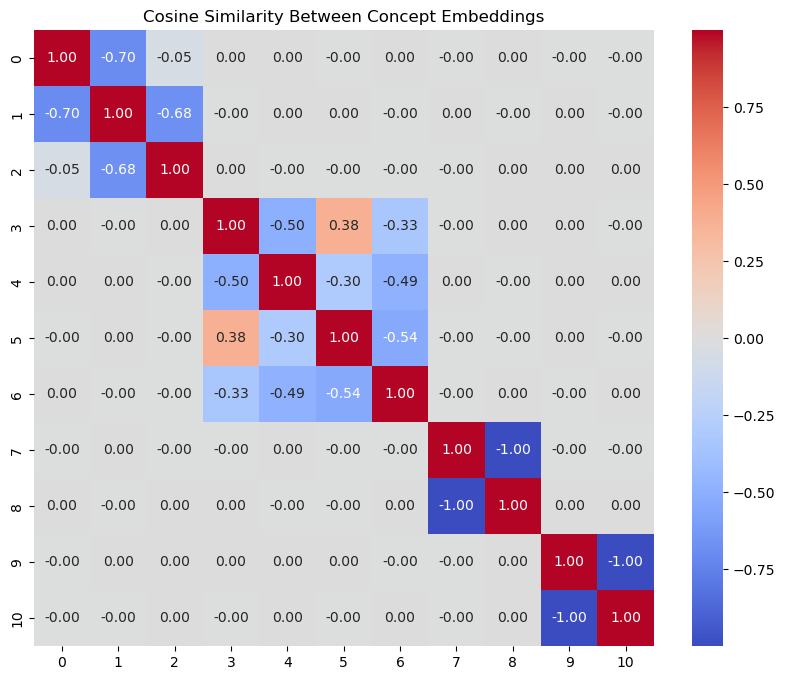

In [8]:
concept_heatmap(concepts, con_label=CON_LABEL, dataset_name=DATASET_NAME) 

# Comparing to Ground Truth

In [28]:
alignment_results, gt_cos_sims = find_closest_to_gt(concepts, cos_sims, DATASET_NAME, PERCENT_THRU_MODEL, 'cls')

In [ ]:
print(alignment_results)

In [29]:
gt_images_per_concept = map_concepts_to_image_indices(dataset_name=DATASET_NAME)
gt_images_per_concept_sorted = sort_mapping_by_split(gt_images_per_concept, DATASET_NAME, sample_type='image')
gt_images_per_concept_train = gt_images_per_concept_sorted['train']
gt_images_per_concept_test = gt_images_per_concept_sorted['test']

## Compute CosSim Thresholds w Concepts Closest to GT

In [36]:
percentile = 0.95

gt_concept_thresholds = compute_concept_thresholds(gt_images_per_concept_test, embeds, 
                                                       gt_cos_sims, percentile, n_vectors=5, device=DEVICE, 
                                                       n_concepts_to_print=6)
gt_fp_count, gt_fn_count, gt_tp_count, gt_tn_count = evaluate_thresholds_across_dataset(gt_concept_thresholds, 
                                                                            gt_images_per_concept_test, 
                                                                            gt_cos_sims, dataset_name=DATASET_NAME,
                                                                           sample_type='image')

Concept thresholds using 95.0%:
Concept color::blue: 0.0915, (random=-0.0570)
Concept color::green: 0.3296, (random=-0.0423)
Concept color::red: 0.2756, (random=-0.0556)
Concept shape::cube: 0.4367, (random=-0.0451)
Concept shape::cylinder: 0.3959, (random=-0.0470)
Concept shape::sphere: 0.5867, (random=-0.0387)


100%|██████████| 6/6 [00:00<00:00, 3490.89it/s]


### Plot them

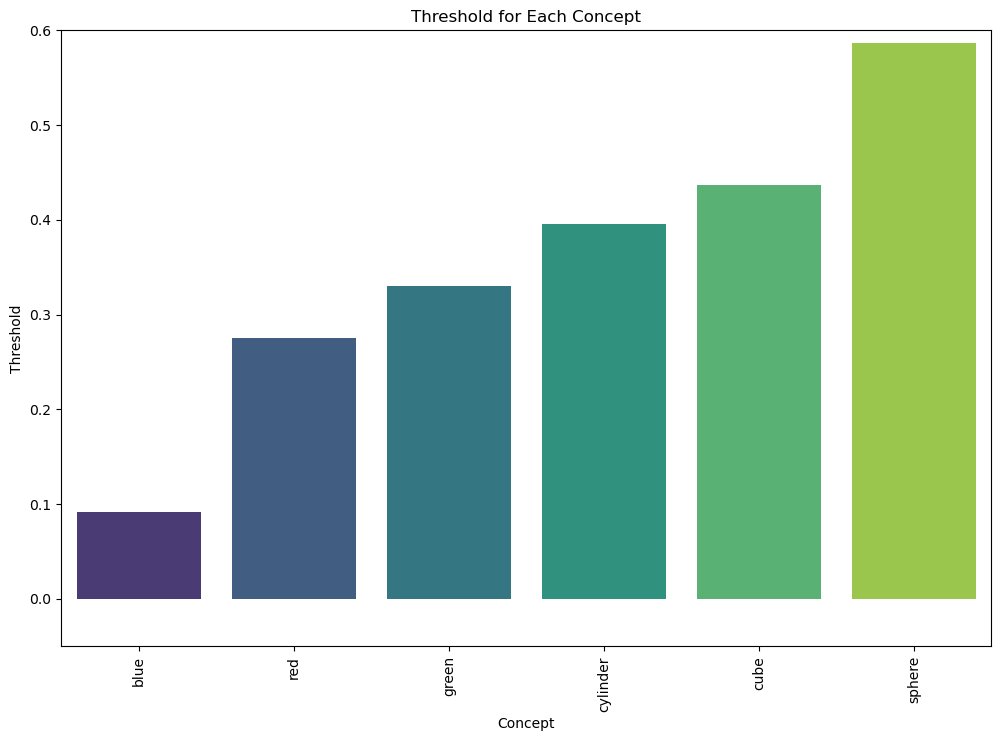

In [38]:
gt_threshold_df = pd.DataFrame({
    "concept": [key.split("::")[1] for key in gt_concept_thresholds.keys()],
    "Threshold": [value[0] for value in gt_concept_thresholds.values()]
})
plot_metric(gt_threshold_df, 'Threshold', y_min=-0.05, y_max=0.6)

## Compute Stats

In [39]:
gt_metrics_df = compute_concept_metrics(gt_fp_count, gt_fn_count, gt_tp_count, gt_tn_count, gt_patch_concepts.keys())
print_threshold_eval_results(gt_metrics_df, print_types=['rate', 'summary'])

Concept: color::blue
TPR: 0.9492, FPR: 0.0571, TNR: 0.9429, FNR: 0.0508

Concept: color::green
TPR: 0.9437, FPR: 0.0000, TNR: 1.0000, FNR: 0.0563

Concept: color::red
TPR: 0.9420, FPR: 0.0000, TNR: 1.0000, FNR: 0.0580

Concept: shape::cube
TPR: 0.9481, FPR: 0.0000, TNR: 1.0000, FNR: 0.0519

Concept: shape::cylinder
TPR: 0.9500, FPR: 0.0000, TNR: 1.0000, FNR: 0.0500

Concept: shape::sphere
TPR: 0.9355, FPR: 0.0000, TNR: 1.0000, FNR: 0.0645


Best and Worst 5 Concepts by Precision (how many of the predicted positives are actually correct):
           concept  precision          concept  precision
0     color::green        1.0      color::blue      0.875
1       color::red        1.0     color::green      1.000
2      shape::cube        1.0       color::red      1.000
3  shape::cylinder        1.0      shape::cube      1.000
4    shape::sphere        1.0  shape::cylinder      1.000

Best and Worst 5 Concepts by Recall (how many of the actual positives were correctly identified):
         

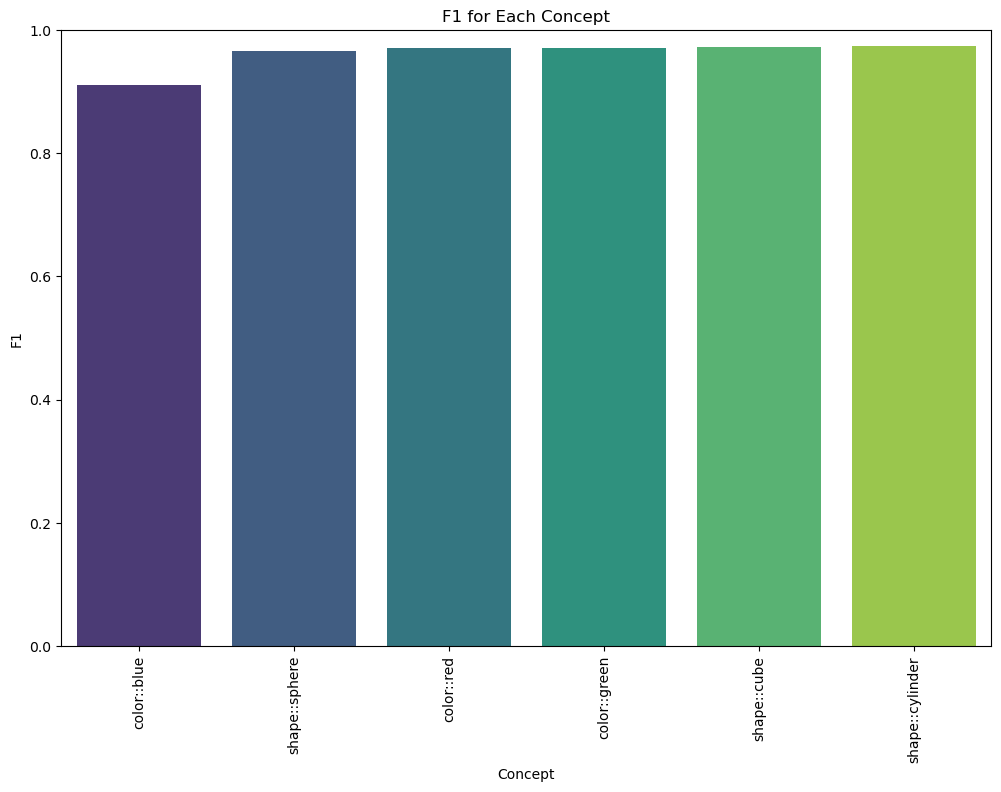

In [51]:
plot_metric(gt_metrics_df, 'f1', y_max=1)

In [43]:
concept_stats = compute_concept_cosine_stats(gt_images_per_concept_test, gt_cos_sims, 
                                             embeds, results_to_print=cos_sims.shape[1], 
                                             device=DEVICE)

Mean and Std of Cossims:
Concept color::blue: mean cossim=0.3502, std=0.1791
          (random: mean cossim=-0.0040, std=0.0284)
Concept color::green: mean cossim=0.4402, std=0.0736
          (random: mean cossim=0.0143, std=0.0393)
Concept color::red: mean cossim=0.4087, std=0.0700
          (random: mean cossim=-0.0007, std=0.0266)
Concept shape::cube: mean cossim=0.6085, std=0.0871
          (random: mean cossim=-0.0075, std=0.0351)
Concept shape::cylinder: mean cossim=0.6193, std=0.1452
          (random: mean cossim=-0.0009, std=0.0320)
Concept shape::sphere: mean cossim=0.7067, std=0.1023
          (random: mean cossim=-0.0024, std=0.0443)


## Histogram

100%|██████████| 6/6 [00:00<00:00, 1448.73it/s]


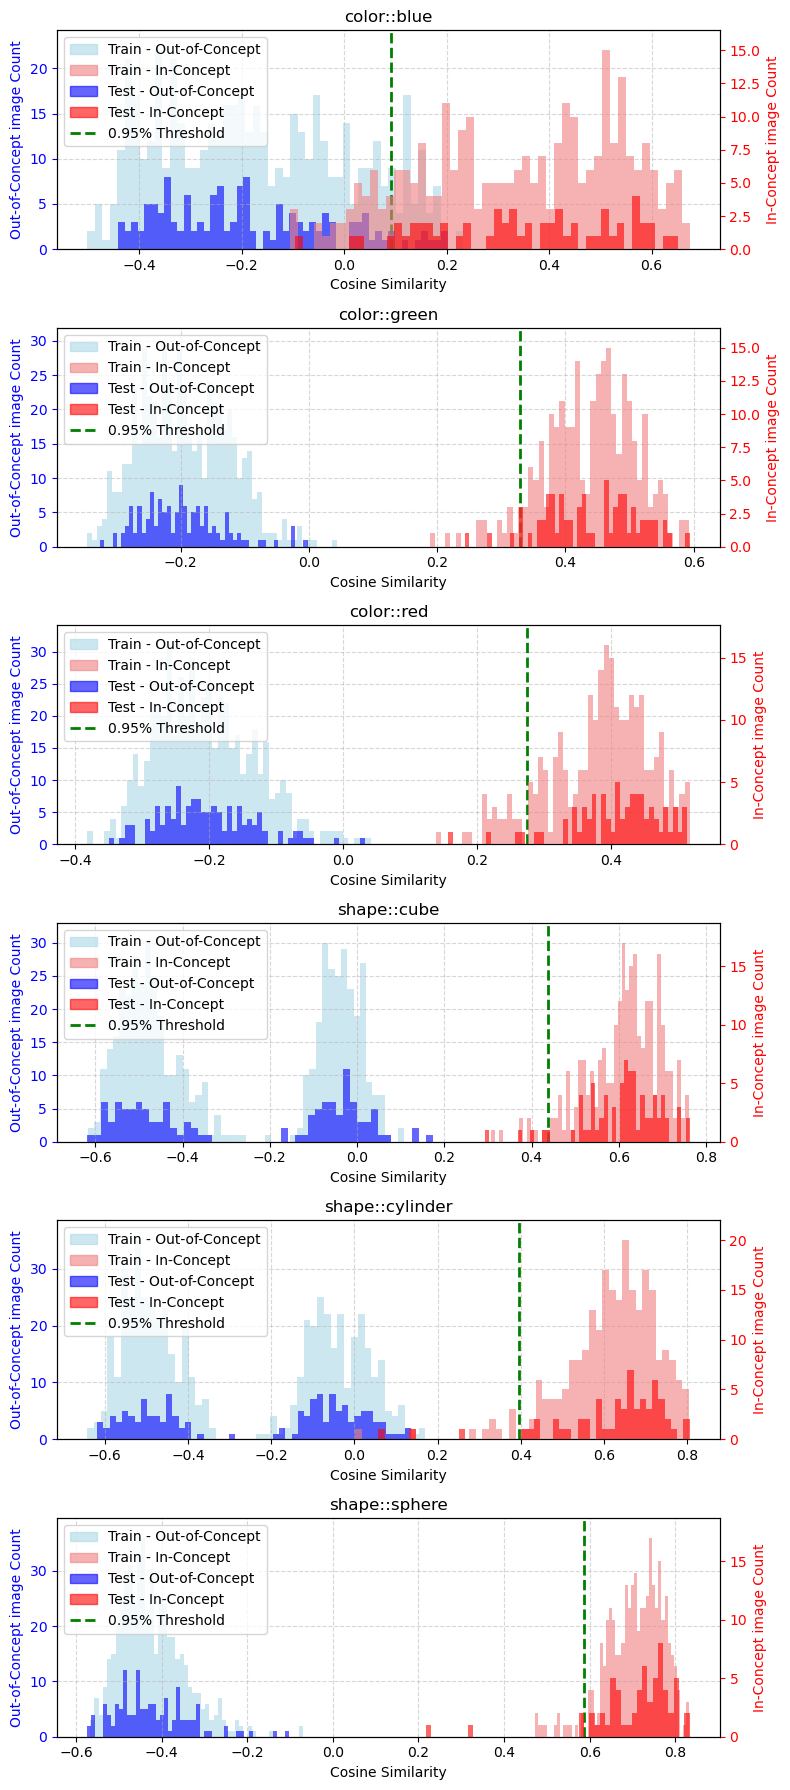

In [46]:
gt_stats = compute_cossim_hist_stats(gt_images_per_concept, gt_cos_sims, 
                                  DATASET_NAME, percentile, sample_type='image')
plot_cosine_similarity_histograms(gt_stats, gt_concept_thresholds, plot_type='both', 
                                  sample_type='image', percentile=percentile)

# Visualize Concepts

## Plot Patches Aligning with Concepts

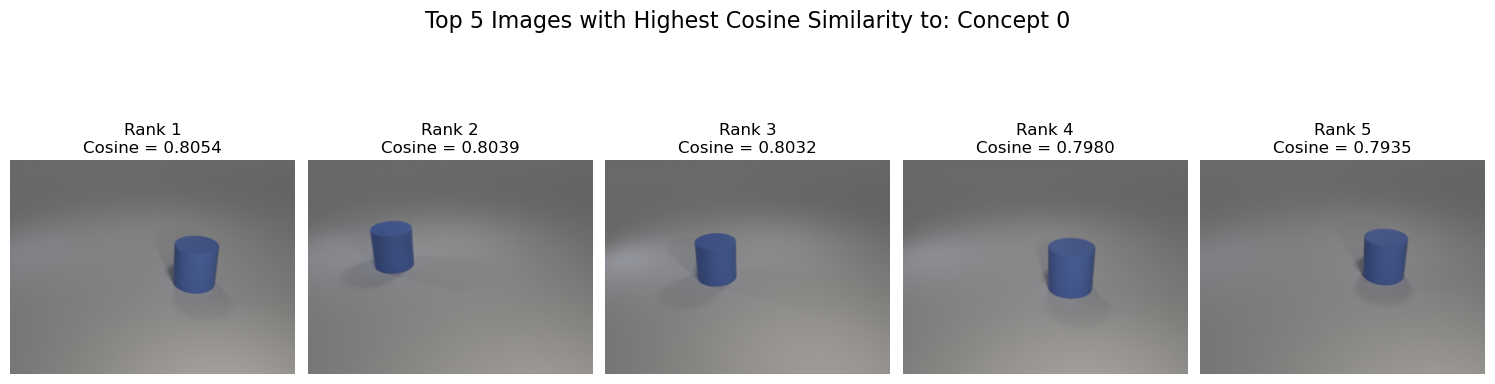

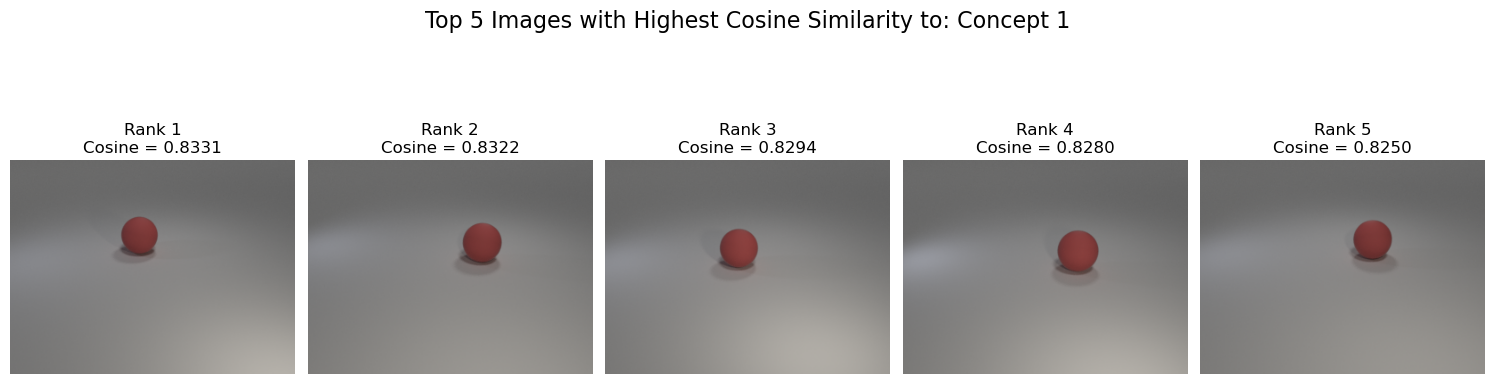

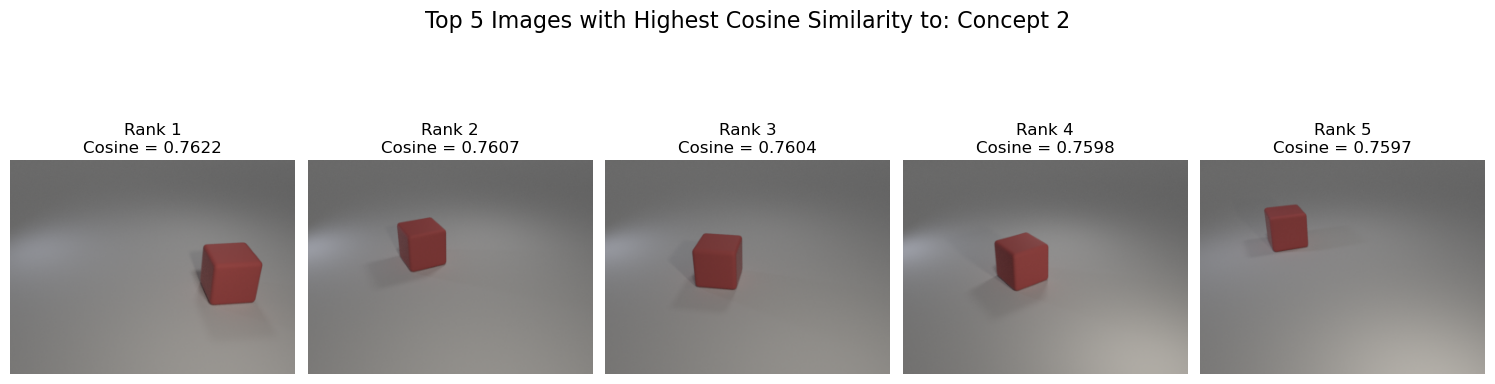

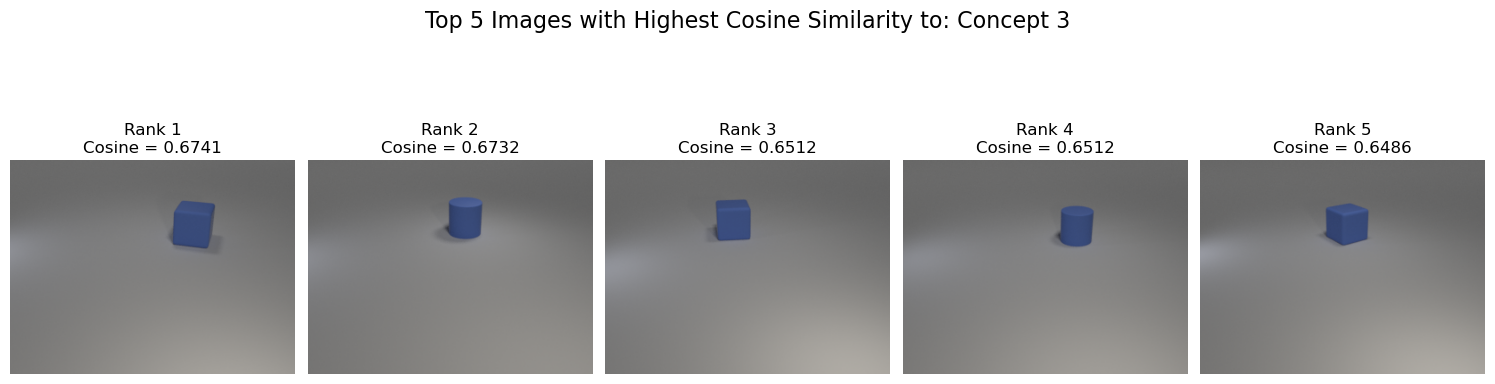

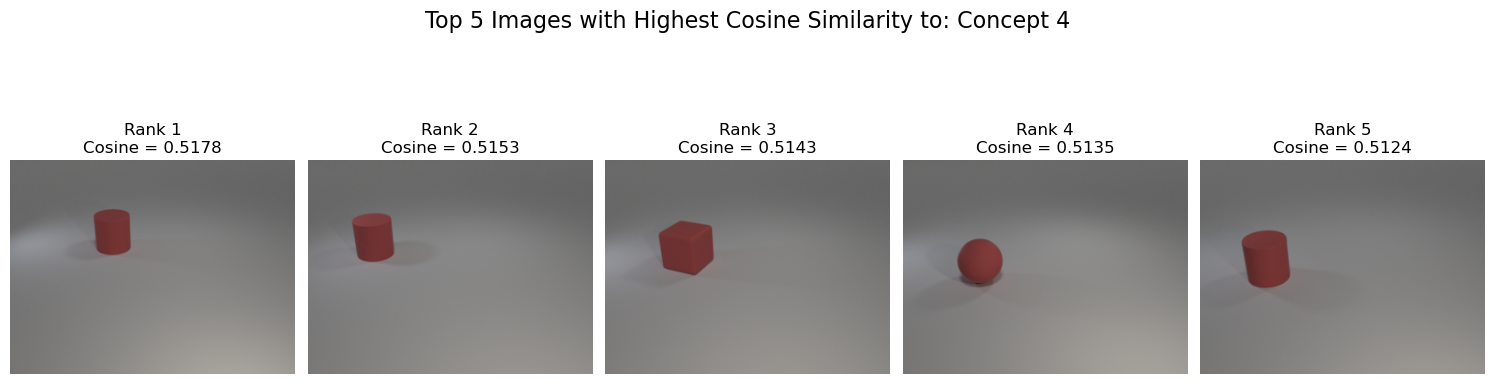

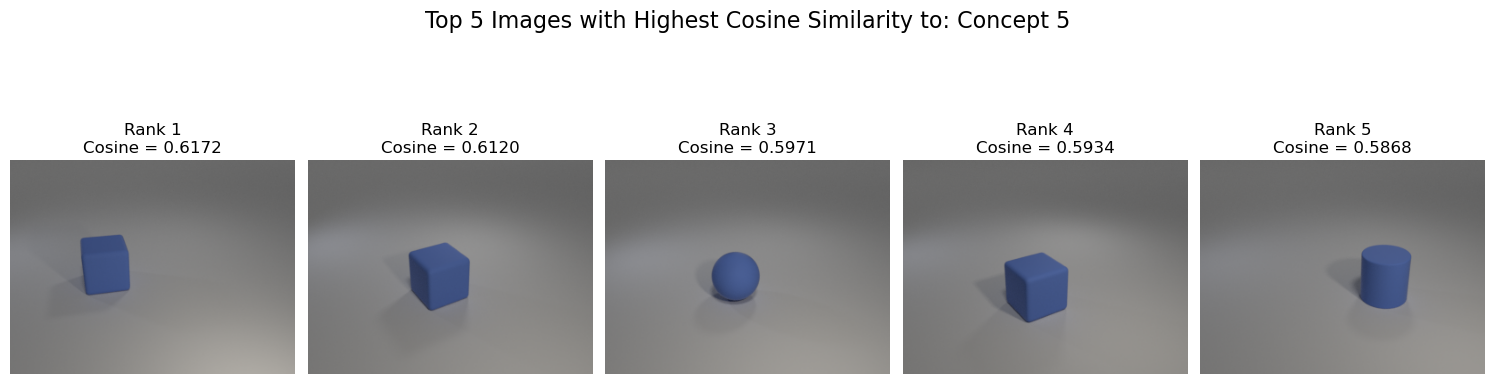

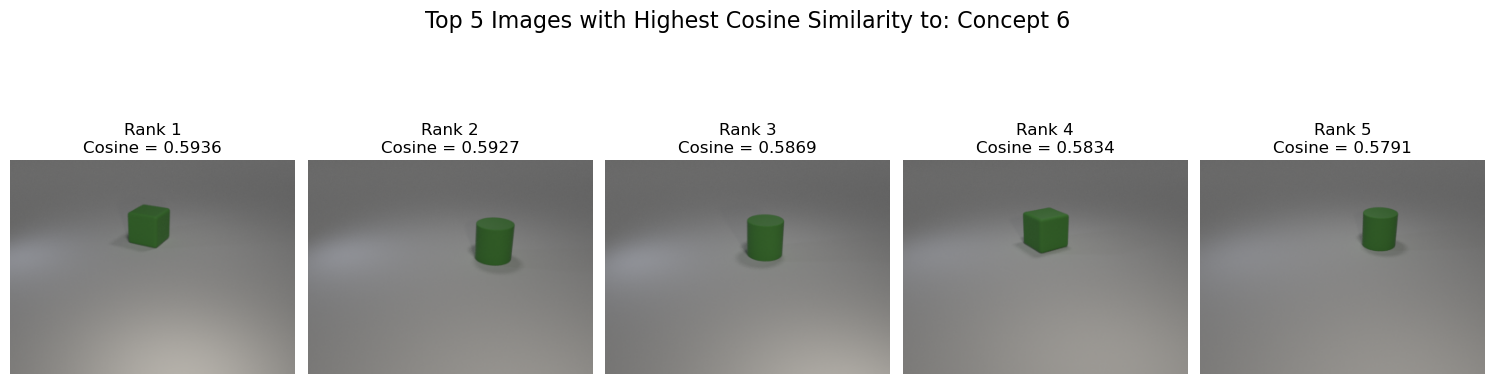

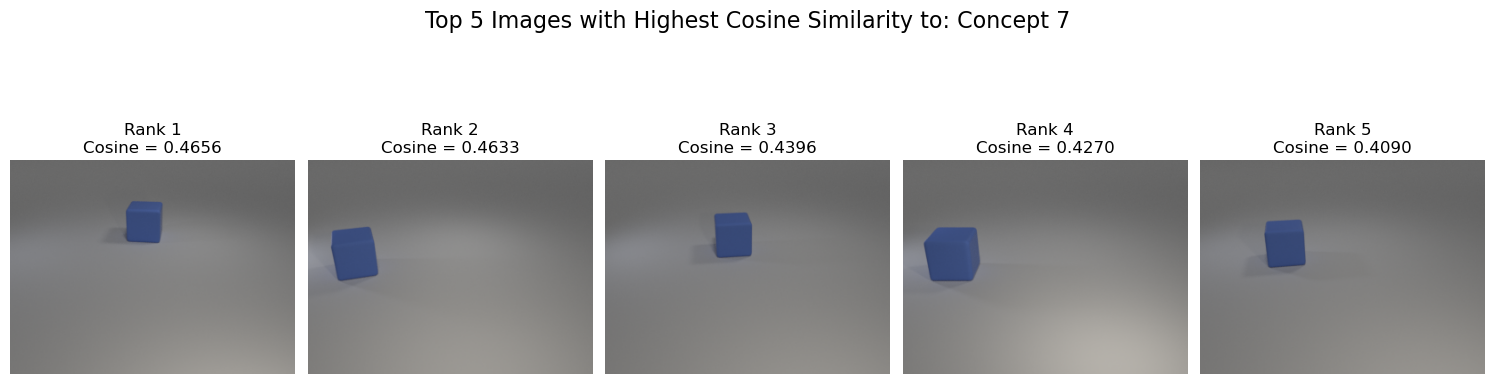

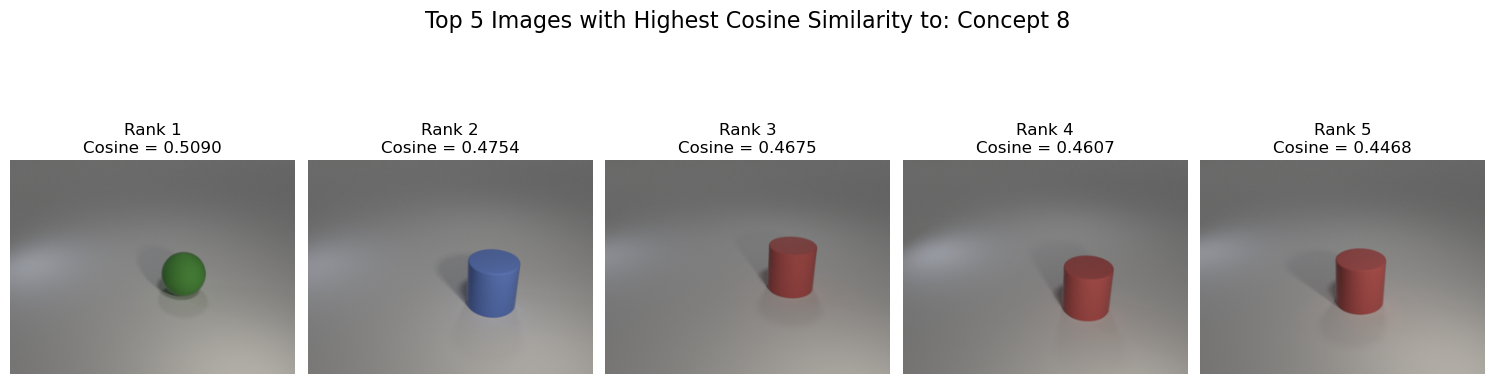

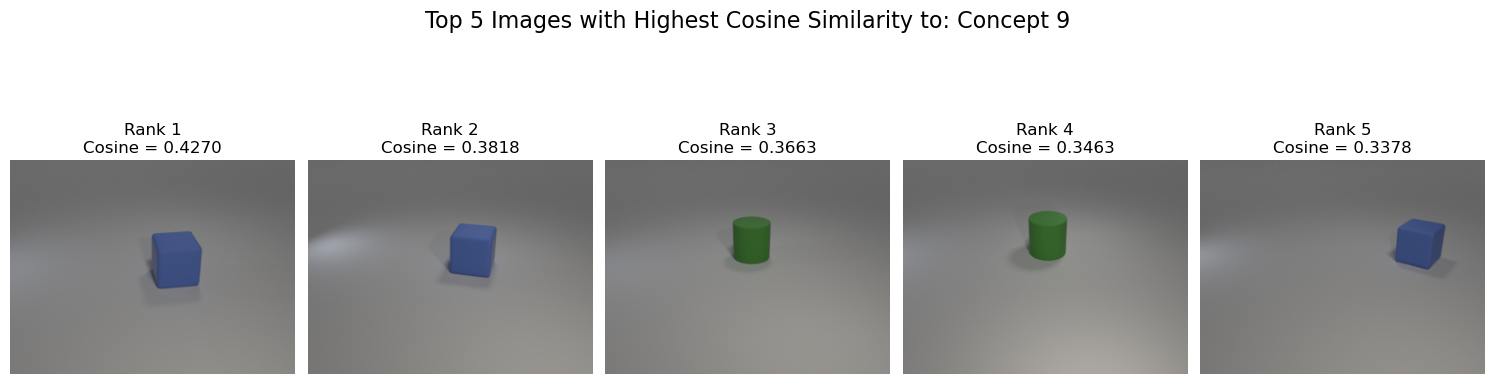

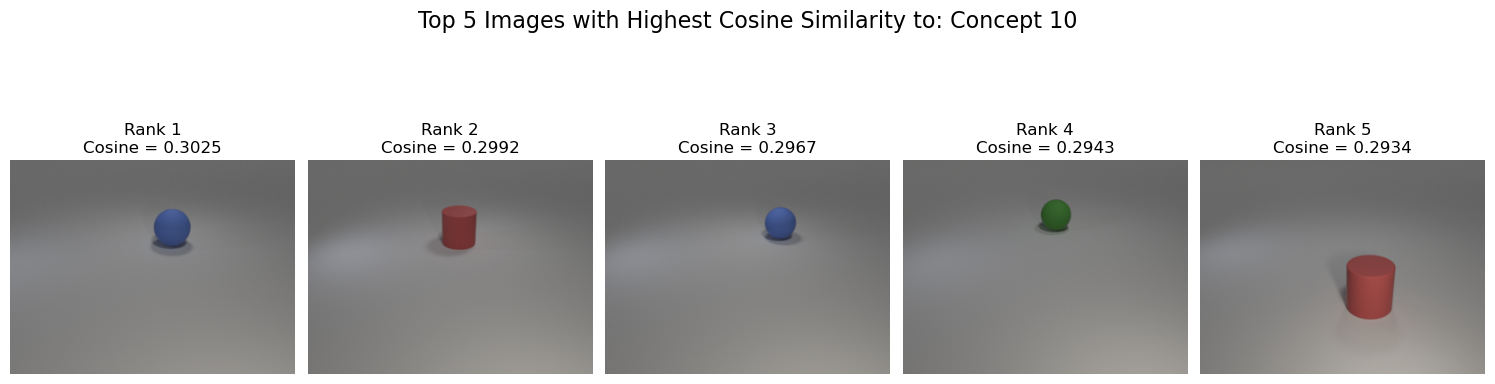

In [48]:
top_n = 5
for i in range(len(concepts.keys())):
    plot_aligned_images(cos_sims, con_label=CON_LABEL, dataset_name=DATASET_NAME, k=top_n,
                       concept_key = str(i))